In [1]:
# Session 13 test

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
import scipy.stats as stats

In [6]:
df = pd.read_csv('C:\AI-MatSci-Lab-varun\Test_AIMATSC.csv')

In [7]:
print(f"Initial row count: {len(df)}")

Initial row count: 5542


In [8]:
# Rename columns to standard schema (formula, T, Cp)[cite: 16]
df = df.rename(columns={'Formula': 'formula', 'Temperature': 'T', 'Heat_Capacity': 'Cp'})

In [9]:
count_before_dropna = len(df)

In [10]:
df.head(10)

,cif_id,agl_bulk_modulus_isothermal_300K,ael_youngs_modulus_vrh
0,Ac1H2_ICSD_56392.cif,50.0551,78.3652
1,Ag1Al1O2_ICSD_160643.cif,116.4680,92.1706
2,Ag1Al1O2_ICSD_300020.cif,142.0890,132.6010
3,Ag1Al1S2_ICSD_25356.cif,70.7537,84.8939
4,Ag1Al1Se2_ICSD_28745.cif,46.9109,47.3356
5,Ag1Al1Te2_ICSD_28746.cif,36.0103,41.0695
6,Ag1As1Ba1_ICSD_8278.cif,38.1864,69.8235
7,Ag1As1Ca1_ICSD_10017.cif,50.0585,89.4192
8,Ag1As1S1_ICSD_604740.cif,44.9812,33.5341
9,Ag1As1Sr1_ICSD_49742.cif,43.5453,75.2405


In [11]:
# Rename columns to standard schema (formula, T, Cp)[cite: 16]
df = df.rename(columns={'cif_id': 'formula', 'agl_bulk_modulus_isothermal_300K': 'T', 'ael_youngs_modulus_vrh': 'Cp'})

In [12]:
count_before_dropna = len(df)

In [13]:
df = df.dropna(subset=['formula', 'T', 'Cp'])

In [14]:
print(f"Rows dropped due to NaN: {count_before_dropna - len(df)}")

Rows dropped due to NaN: 12


In [15]:
df = df.dropna(subset=['formula', 'T', 'Cp'])

In [16]:
print(f"Rows dropped due to NaN: {count_before_dropna - len(df)}")

Rows dropped due to NaN: 12


In [18]:
valid_mask = (df['T'] >= 0) & (df['Cp'] >= 0)

In [19]:
dropped_unphysical = (~valid_mask).sum()

In [20]:
print(f"Rows dropped due to unphysical values (T < 0 or Cp < 0): {dropped_unphysical}")

Rows dropped due to unphysical values (T < 0 or Cp < 0): 0


In [21]:
df_clean = df[valid_mask].copy()

In [22]:
print(f"Final cleaned dataset row count: {len(df_clean)}")

Final cleaned dataset row count: 5530


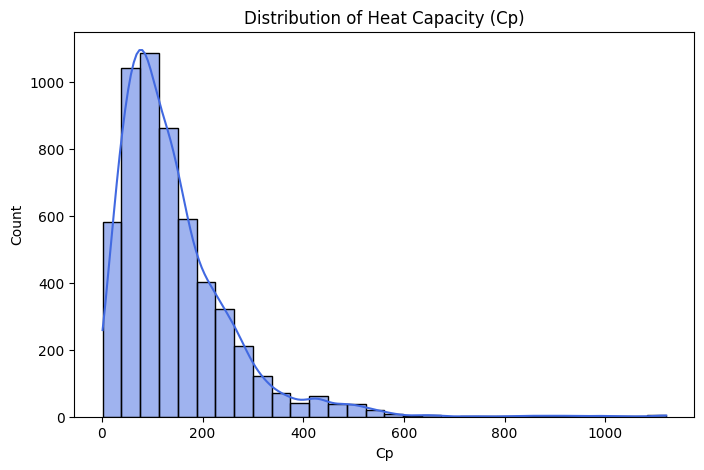

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Cp'], kde=True, bins=30, color='royalblue')
plt.title('Distribution of Heat Capacity (Cp)')
plt.xlabel('Cp')
plt.ylabel('Count')
plt.show()

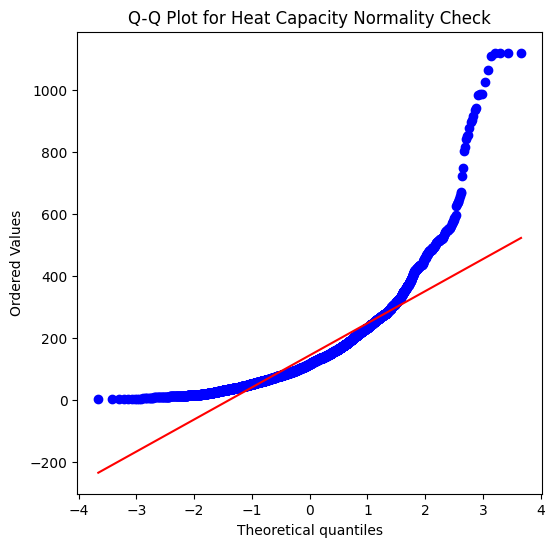

In [24]:
# 6. Perform a Q-Q normality check[cite: 16]
plt.figure(figsize=(6, 6))
stats.probplot(df_clean['Cp'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Heat Capacity Normality Check')
plt.show()

In [25]:
# Save the cleaned dataset deliverable
df_clean.to_csv('cleaned_cp_dataset.csv', index=False)
print("✅ Cleaned Cp dataset successfully saved and ready for commit.")

✅ Cleaned Cp dataset successfully saved and ready for commit.
